<a href="https://colab.research.google.com/github/Ammar-creator-cmd/DataVisualization/blob/main/DigitRecognition1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist

In [42]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train.shape

(60000, 28, 28)

In [91]:
# Run this BEFORE building and fitting your model!
x_train = x_train / 255.0
x_test = x_test / 255.0

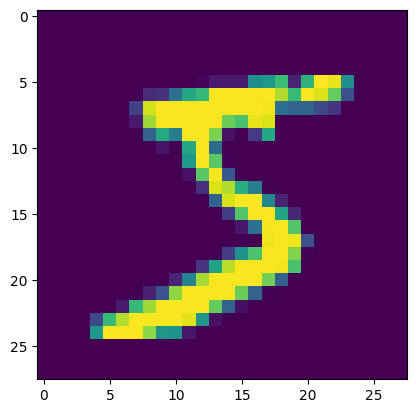

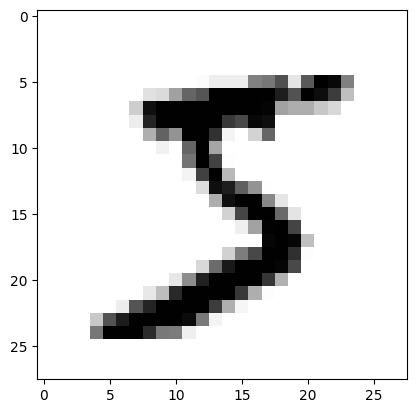

In [43]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
plt.show()
plt.imshow(x_train[0], cmap = plt.cm.binary)

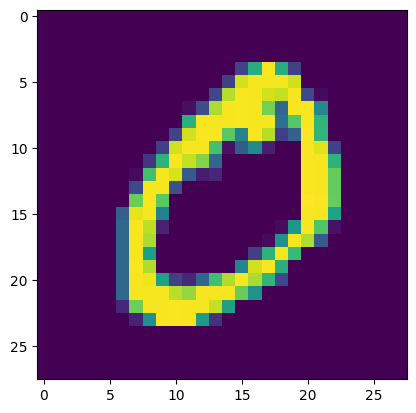

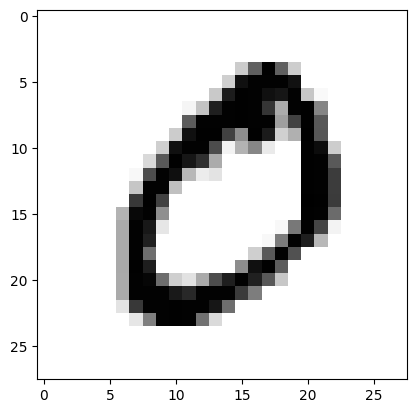

In [44]:
import matplotlib.pyplot as plt

plt.imshow(x_train[1])
plt.show()
plt.imshow(x_train[1], cmap = plt.cm.binary)

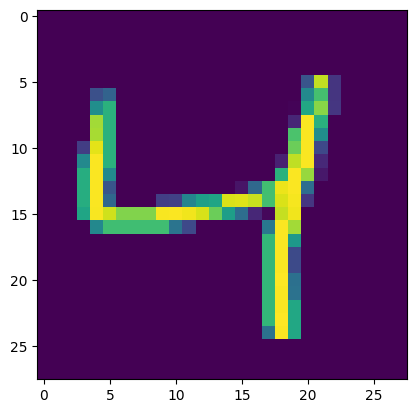

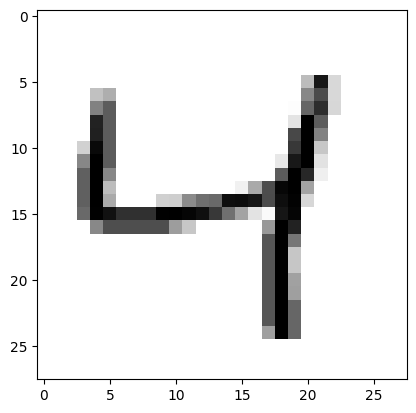

In [45]:
import matplotlib.pyplot as plt

plt.imshow(x_train[2])
plt.show()
plt.imshow(x_train[2], cmap = plt.cm.binary)

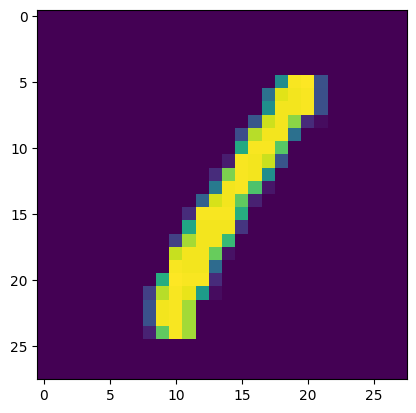

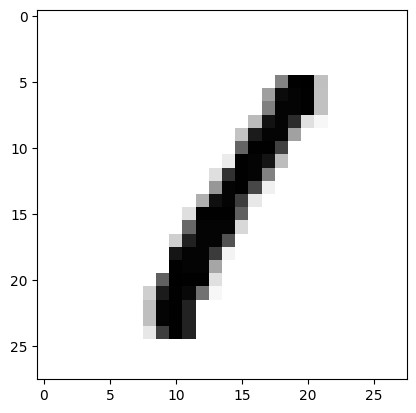

In [46]:
import matplotlib.pyplot as plt

plt.imshow(x_train[3])
plt.show()
plt.imshow(x_train[3], cmap = plt.cm.binary)

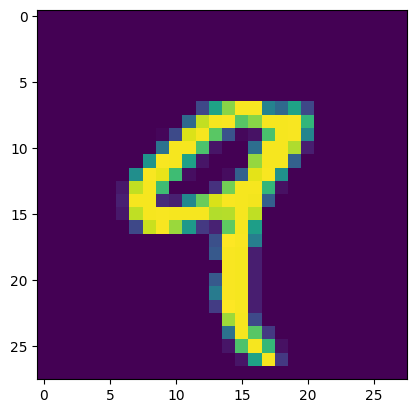

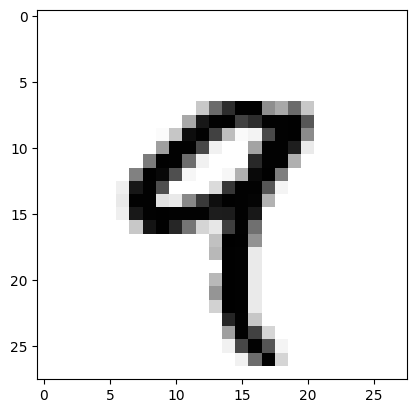

In [47]:
import matplotlib.pyplot as plt

plt.imshow(x_train[4])
plt.show()
plt.imshow(x_train[4], cmap = plt.cm.binary)

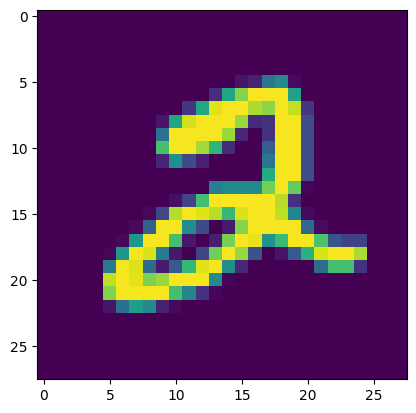

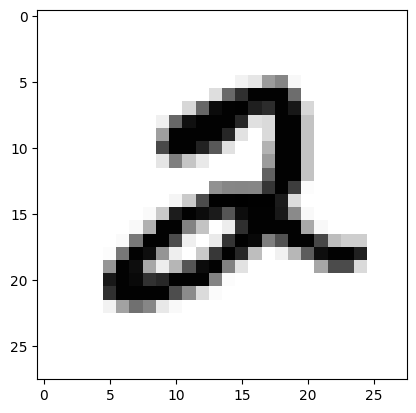

In [48]:
import matplotlib.pyplot as plt

plt.imshow(x_train[5])
plt.show()
plt.imshow(x_train[5], cmap = plt.cm.binary)

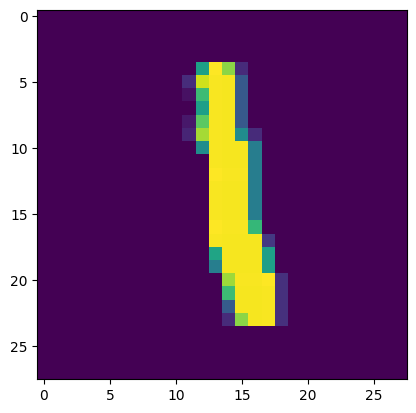

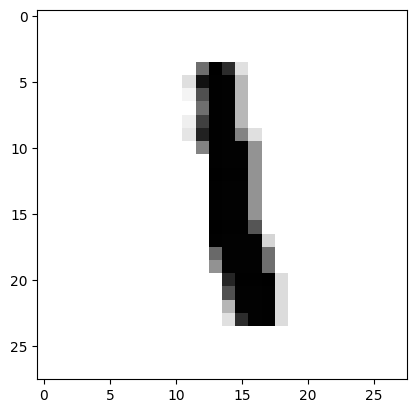

In [49]:
import matplotlib.pyplot as plt

plt.imshow(x_train[6])
plt.show()
plt.imshow(x_train[6], cmap = plt.cm.binary)

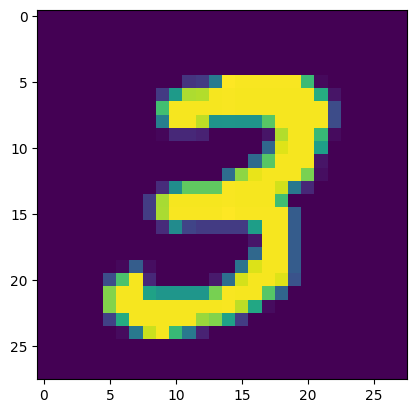

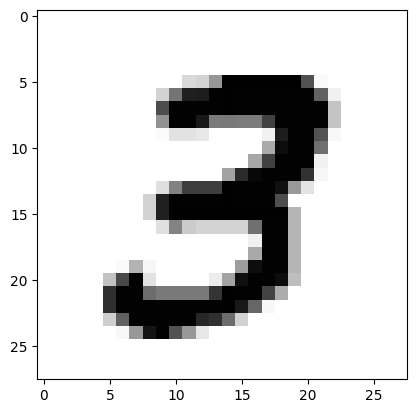

In [50]:
import matplotlib.pyplot as plt

plt.imshow(x_train[7])
plt.show()
plt.imshow(x_train[7], cmap = plt.cm.binary)

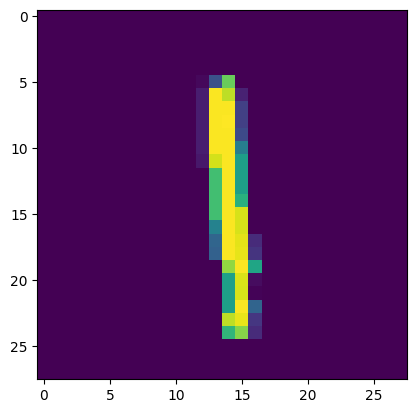

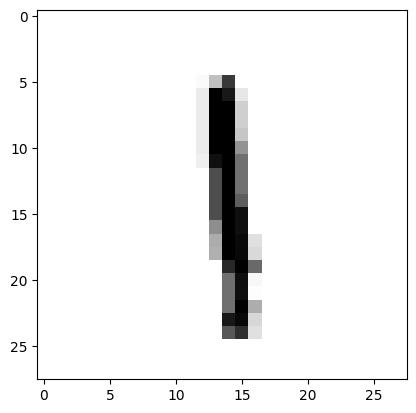

In [51]:
import matplotlib.pyplot as plt

plt.imshow(x_train[8])
plt.show()
plt.imshow(x_train[8], cmap = plt.cm.binary)

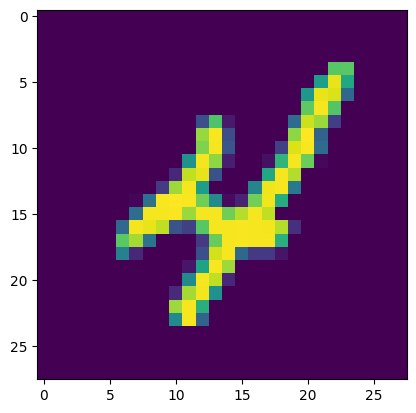

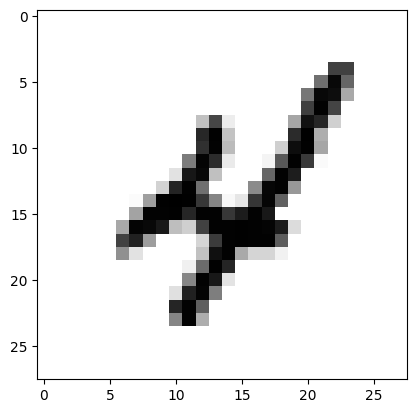

In [52]:
import matplotlib.pyplot as plt

plt.imshow(x_train[9])
plt.show()
plt.imshow(x_train[9], cmap = plt.cm.binary)

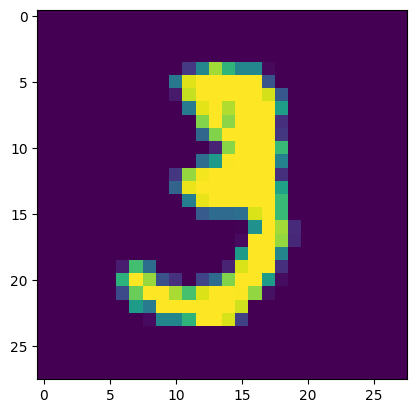

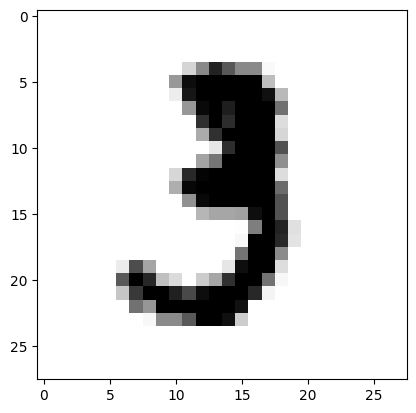

In [53]:
import matplotlib.pyplot as plt

plt.imshow(x_train[10])
plt.show()
plt.imshow(x_train[10], cmap = plt.cm.binary)

### Part 2


In [54]:
import numpy as np
img_size = 28
x_trainer = np.array(x_train).reshape(-1, img_size, img_size, 1)
x_tester = np.array(x_test).reshape(-1, img_size, img_size, 1)
print("Training shape", x_trainer.shape)
print("Testing shape", x_tester.shape)

Training shape (60000, 28, 28, 1)
Testing shape (10000, 28, 28, 1)


In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

model = Sequential()

model.add(Conv2D(32, (3, 3), activation = "relu", input_shape = x_trainer.shape[1:]))
#model.add(MaxPooling2D((2, 2)))

In [56]:
model.add(Conv2D(64 , (3,3) , activation = 'relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))
# model.add(Conv2D(64 , (3,3) , activation = 'relu'))
# model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation = 'softmax'))

In [57]:
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [59]:
model.fit(x_trainer,y_train, epochs = 8, validation_split = 0.3 , batch_size = 128,verbose=1)

Epoch 1/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 144s 439ms/step - accuracy: 0.9874 - loss: 0.0393 - val_accuracy: 0.9872 - val_loss: 0.0537
Epoch 2/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 145s 440ms/step - accuracy: 0.9877 - loss: 0.0390 - val_accuracy: 0.9872 - val_loss: 0.0486
Epoch 3/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 138s 420ms/step - accuracy: 0.9900 - loss: 0.0322 - val_accuracy: 0.9855 - val_loss: 0.0590
Epoch 4/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 144s 426ms/step - accuracy: 0.9889 - loss: 0.0356 - val_accuracy: 0.9871 - val_loss: 0.0579
Epoch 5/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 140s 420ms/step - accuracy: 0.9911 - loss: 0.0270 - val_accuracy: 0.9869 - val_loss: 0.0663
Epoch 6/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 145s 439ms/step - accuracy: 0.9887 - loss: 0.0354 - val_accuracy: 0.9876 - val_loss: 0.0575
Epoch 7/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 143s 434ms/step - accuracy: 0.9909 - loss: 0.0268 - val_accuracy: 0.9883 - val_loss: 0.0590
Epoch 8/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 135s 411ms/step - accuracy: 0.9906 - loss: 0

### Task 3

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_custom_image(image_path):
    # Load image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Check if image was loaded successfully
    if img is None:
        print(f"Error: Could not load image from {image_path}. Please ensure the file exists and the path is correct.")
        return

    # Resize to 28x28 pixels
    img_resized = cv2.resize(img, (28, 28))

    # Invert colors if you wrote with black ink on white paper
    # (MNIST is white text on a black background)
    img_inverted = cv2.bitwise_not(img_resized)

    # Normalize pixel values
    img_normalized = img_inverted / 255.0

    # Reshape for the model (add batch dimension)
    img_input = np.reshape(img_normalized, (1, 28, 28))
    # Note: If using a CNN, you might need (1, 28, 28, 1) depending on your input shape

    # Predict
    prediction = model.predict(img_input)
    predicted_digit = np.argmax(prediction)

    # Show the processed image and prediction
    plt.imshow(img_inverted, cmap='gray')
    plt.title(f"Predicted Digit: {predicted_digit}")
    plt.axis('off')
    plt.show()

# Run it on your uploaded image
predict_custom_image('image_222a60.png')

Error: Could not load image from image_222a60.png. Please ensure the file exists and the path is correct.


In [102]:
from google.colab import files
# Use this to upload your image file (e.g., image_222a60.png)
uploaded1 = files.upload()
# Use this to upload your image file (e.g., image_222a60.png)
uploaded1 = files.upload()
# Cell 1: Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()



# Cell 2: Normalize training data (DON'T SKIP THIS!)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Cell 3: Define & Compile Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Cell 4: Train it
model.fit(x_train, y_train, epochs=5)

# Cell 5: Test your custom image (your current block)
# ... (your PIL image loading and model.predict code here)

# List files to verify upload
import os
print("Current files in directory:", os.listdir('.'))

Saving 4.jpg to 4 (3).jpg


Saving 3.png to 3.png


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9245 - loss: 0.2620
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9654 - loss: 0.1159
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9753 - loss: 0.0800
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9812 - loss: 0.0601
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9857 - loss: 0.0462
Current files in directory: ['.config', '4 (2).jpg', '4.jpg', 'drive', '4 (1).jpg', '3.png', '4 (3).jpg', 'sample_data']


In [94]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

313/313 - 1s - 2ms/step - accuracy: 0.9752 - loss: 0.0817

Test accuracy: 0.9752


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


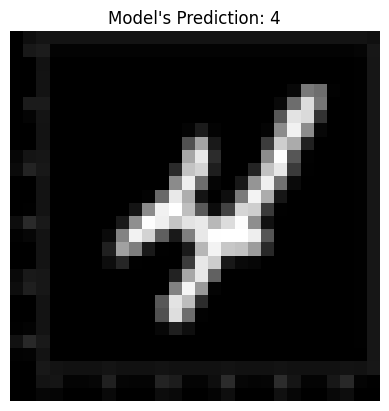

The model thinks this digit is: 4


In [99]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load, convert to grayscale, and resize
img = Image.open('4.jpg').convert('L')
img = img.resize((28, 28))

# Convert to numpy array and normalize to range 0-1
img_array = np.array(img) / 255.0

# --- FIX: Invert the colors if it's black text on a white background ---
img_array = 1.0 - img_array

# Expand dimensions to create a batch (1, 28, 28)
img_input = np.expand_dims(img_array, axis=0)

# Re-run prediction
predictions = model.predict(img_input)

# FIX: Define predicted_digit so the code doesn't crash!
predicted_digit = np.argmax(predictions)

# Display the processed image and the prediction result
plt.imshow(img_array, cmap='gray')
plt.title(f"Model's Prediction: {predicted_digit}")
plt.axis('off')
plt.show()

print(f"The model thinks this digit is: {predicted_digit}")